# Chapter 11.4: Bias in Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Identify and measure popularity bias** in recommendation systems
2. **Understand position bias** and how it distorts click data
3. **Recognise selection bias** and its impact on model training
4. **Explain conformity bias** and exposure bias in user feedback
5. **Implement debiasing methods** including IPW, causal models, and balanced sampling
6. **Detect popularity bias** using Gini index and long-tail analysis
7. **Correct position bias** using click models and propensity estimation

## Prerequisites

- Chapters 11.1-11.3 (especially counterfactual evaluation)
- Basic understanding of causal inference concepts
- Familiarity with collaborative filtering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part11/chapter_11.4_bias.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part11/chapter_11.4_bias.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from collections import Counter

np.random.seed(42)
plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. Popularity Bias

Popularity bias is the most pervasive bias in recommendation systems. Popular items get more exposure, which leads to more clicks, which generates more training data, reinforcing their popularity.

$$\text{Feedback loop: } \text{Popular} \rightarrow \text{More exposure} \rightarrow \text{More clicks} \rightarrow \text{More training data} \rightarrow \text{Higher score} \rightarrow \text{More exposure}$$

Reference: Abdollahpouri et al., "The Unfairness of Popularity Bias in Recommendation" (RecSys Workshop 2019).

> **💡 Concept:** The "long tail" of items (niche, less popular) may be highly relevant to specific users but never gets recommended because the model has insufficient data about them.

In [2]:
# Simulate items with Zipf-like popularity distribution
rng = np.random.RandomState(42)
NUM_ITEMS = 1000
NUM_USERS = 500

# Item popularity follows Zipf's law
item_ranks = np.arange(1, NUM_ITEMS + 1)
item_popularity = 1.0 / (item_ranks ** 0.8)
item_popularity /= item_popularity.sum()

# True relevance: items have latent quality (independent of popularity)
item_quality = rng.uniform(0.2, 0.9, NUM_ITEMS)

# Simulate interaction data: users interact based on BOTH relevance and exposure
# Biased model: P(interact) ~ popularity * quality
# Unbiased model: P(interact) ~ quality only

interactions = []
for u in range(NUM_USERS):
    user_prefs = rng.randn(NUM_ITEMS) * 0.3  # per-user preference noise
    # Number of items seen (exposure is popularity-biased)
    n_exposed = 50
    exposed_items = rng.choice(NUM_ITEMS, size=n_exposed, replace=False, p=item_popularity)
    
    for item in exposed_items:
        # Click probability depends on true quality + user preference
        click_prob = expit(2 * item_quality[item] + user_prefs[item] - 1.0)
        clicked = rng.random() < click_prob
        interactions.append({
            'user_id': u, 'item_id': item, 'clicked': int(clicked),
            'item_popularity_rank': item_ranks[item],
            'item_quality': item_quality[item]
        })

inter_df = pd.DataFrame(interactions)
print(f"Total interactions: {len(inter_df)}")
print(f"Unique items exposed: {inter_df['item_id'].nunique()} / {NUM_ITEMS}")
print(f"Click rate: {inter_df['clicked'].mean():.4f}")

Total interactions: 25000
Unique items exposed: 1000 / 1000
Click rate: 0.5143


Gini Index of exposure: 0.5201 (1.0 = maximum inequality)


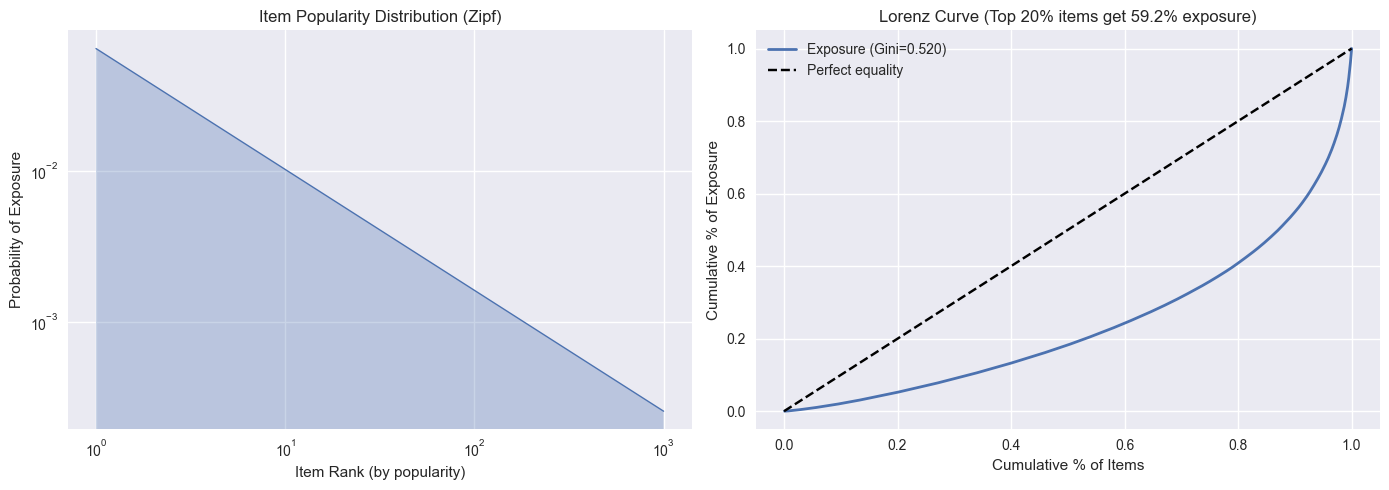

In [3]:
# Measure popularity bias
item_exposure_counts = Counter(inter_df['item_id'])
all_counts = np.array([item_exposure_counts.get(i, 0) for i in range(NUM_ITEMS)])

# Gini index of exposure
sorted_counts = np.sort(all_counts)
n = len(sorted_counts)
index = np.arange(1, n + 1)
total = sorted_counts.sum()
gini = (2 * np.sum(index * sorted_counts) / (n * total)) - (n + 1) / n if total > 0 else 0
print(f"Gini Index of exposure: {gini:.4f} (1.0 = maximum inequality)")

# Plot popularity distribution and exposure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(item_ranks, item_popularity, linewidth=1)
axes[0].fill_between(item_ranks, item_popularity, alpha=0.3)
axes[0].set_xlabel('Item Rank (by popularity)')
axes[0].set_ylabel('Probability of Exposure')
axes[0].set_title('Item Popularity Distribution (Zipf)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Top-20% items get what % of exposure?
top_20_pct = int(0.2 * NUM_ITEMS)
sorted_exposure = np.sort(all_counts)[::-1]
top_20_exposure = sorted_exposure[:top_20_pct].sum() / total * 100

# Lorenz curve
cum_items = np.arange(1, n + 1) / n
cum_exposure = np.cumsum(sorted_counts) / total
axes[1].plot(cum_items, cum_exposure, linewidth=2, label=f'Exposure (Gini={gini:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect equality')
axes[1].set_xlabel('Cumulative % of Items')
axes[1].set_ylabel('Cumulative % of Exposure')
axes[1].set_title(f'Lorenz Curve (Top 20% items get {top_20_exposure:.1f}% exposure)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Position Bias

Users are more likely to click items at higher positions, regardless of relevance:

$$P(\text{click} | \text{item}, \text{position}) = P(\text{examine} | \text{position}) \cdot P(\text{click} | \text{examined}, \text{item})$$

This is the **examination hypothesis** (Richardson et al., 2007). Items at position 1 are examined almost always; items at position 10 are examined rarely.

> **⚠️ Common Pitfall:** Training a model on raw click data treats "not clicked" items at low positions as "not relevant" — but they may simply not have been seen.

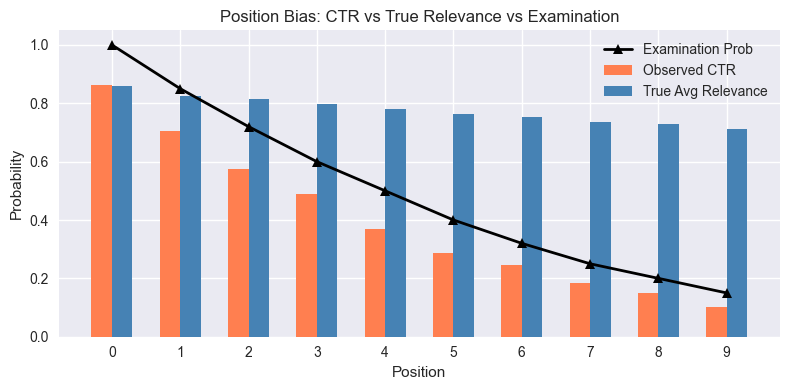

In [4]:
# Simulate position bias in a search/recommendation setting
NUM_QUERIES = 2000
LIST_SIZE = 10
NUM_CANDIDATES = 50

# Position examination probabilities
position_exam = np.array([1.0, 0.85, 0.72, 0.60, 0.50, 0.40, 0.32, 0.25, 0.20, 0.15])

# Generate queries with candidate items
query_relevance = rng.uniform(0, 1, size=(NUM_QUERIES, NUM_CANDIDATES))

# Logging policy: rank by estimated relevance (noisy)
noisy_scores = query_relevance + rng.randn(NUM_QUERIES, NUM_CANDIDATES) * 0.3
logged_rankings = np.argsort(-noisy_scores, axis=1)[:, :LIST_SIZE]

# Generate clicks with position bias
click_data = []
for q in range(NUM_QUERIES):
    for pos in range(LIST_SIZE):
        item = logged_rankings[q, pos]
        relevance = query_relevance[q, item]
        examined = rng.random() < position_exam[pos]
        clicked = examined and (rng.random() < relevance)
        click_data.append({
            'query_id': q, 'item_id': item, 'position': pos,
            'true_relevance': relevance, 'clicked': int(clicked)
        })

click_df = pd.DataFrame(click_data)

# Show CTR by position
ctr_by_pos = click_df.groupby('position')['clicked'].mean()
avg_rel_by_pos = click_df.groupby('position')['true_relevance'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(LIST_SIZE) - 0.15, ctr_by_pos.values, 0.3, label='Observed CTR', color='coral')
ax.bar(np.arange(LIST_SIZE) + 0.15, avg_rel_by_pos.values, 0.3, label='True Avg Relevance', color='steelblue')
ax.plot(np.arange(LIST_SIZE), position_exam, 'k^-', label='Examination Prob', linewidth=2)
ax.set_xlabel('Position')
ax.set_ylabel('Probability')
ax.set_title('Position Bias: CTR vs True Relevance vs Examination')
ax.legend()
ax.set_xticks(np.arange(LIST_SIZE))
plt.tight_layout()
plt.show()

## 3. Selection Bias and Exposure Bias

**Selection bias**: We only observe outcomes for items that were shown. The missing data is not random — it depends on the recommendation policy.

**Exposure bias**: The model can only learn from items it has exposed to users. This creates a self-reinforcing loop.

**Conformity bias**: Users tend to rate items in line with the average rating or social norms, not their true preference.

Reference: Marlin & Zemel, "Collaborative Prediction and Ranking with Non-Random Missing Data" (RecSys 2009).

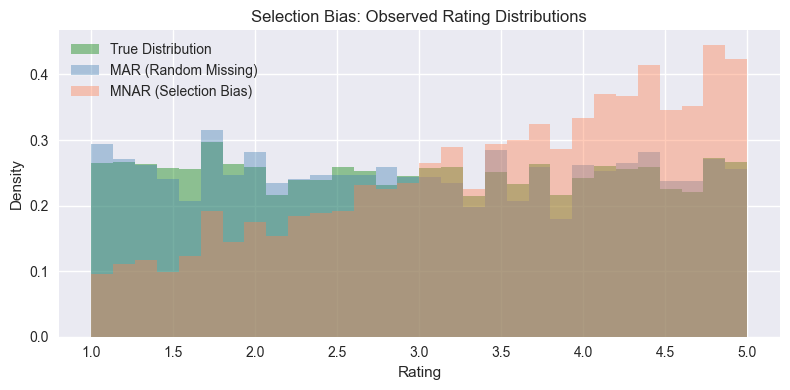

True mean rating:  2.977
MAR observed mean: 2.979
MNAR observed mean: 3.451 (upward bias!)


In [5]:
# Demonstrate selection bias: compare MNAR (Missing Not At Random) vs MAR
# True preference matrix
n_users, n_items = 100, 50
true_ratings = rng.uniform(1, 5, size=(n_users, n_items))

# MNAR: users are more likely to rate items they like
# P(observe) increases with rating
observe_prob_mnar = expit(0.8 * (true_ratings - 3))  # higher rating -> more likely observed
observed_mnar = rng.random((n_users, n_items)) < observe_prob_mnar

# MAR: observe at random with same overall rate
observe_rate = observed_mnar.mean()
observed_mar = rng.random((n_users, n_items)) < observe_rate

# Compare observed rating distributions
ratings_mnar = true_ratings[observed_mnar]
ratings_mar = true_ratings[observed_mar]
ratings_all = true_ratings.flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_all, bins=30, alpha=0.4, density=True, label='True Distribution', color='green')
ax.hist(ratings_mar, bins=30, alpha=0.4, density=True, label='MAR (Random Missing)', color='steelblue')
ax.hist(ratings_mnar, bins=30, alpha=0.4, density=True, label='MNAR (Selection Bias)', color='coral')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_title('Selection Bias: Observed Rating Distributions')
ax.legend()
plt.tight_layout()
plt.show()

print(f"True mean rating:  {ratings_all.mean():.3f}")
print(f"MAR observed mean: {ratings_mar.mean():.3f}")
print(f"MNAR observed mean: {ratings_mnar.mean():.3f} (upward bias!)")

## 4. Debiasing Methods

### 4.1 Inverse Propensity Weighting (IPW)

Re-weight each observation by the inverse of its propensity (probability of being observed):

$$\hat{R} = \frac{\sum_{(u,i) \in \mathcal{O}} \frac{r_{ui}}{P(o_{ui}=1)}}{\sum_{(u,i) \in \mathcal{O}} \frac{1}{P(o_{ui}=1)}}$$

### 4.2 Position Bias Correction

Use the examination hypothesis to separate position effects from relevance.

In [6]:
# Debiasing popularity bias with IPW
# Step 1: Estimate propensity as item popularity
item_prop = np.zeros(NUM_ITEMS)
for i in range(NUM_ITEMS):
    item_prop[i] = max(item_popularity[i], 1e-6)  # avoid division by zero

# Step 2: IPW-corrected metric
# Compare naive CTR (biased) vs IPW-corrected CTR for popular vs unpopular items

inter_df['is_popular'] = inter_df['item_popularity_rank'] <= 200  # top 20%
inter_df['propensity'] = inter_df['item_id'].apply(lambda x: item_prop[x])
inter_df['ipw_weight'] = 1.0 / inter_df['propensity']
# Normalise weights
inter_df['ipw_weight'] = inter_df['ipw_weight'] / inter_df['ipw_weight'].sum() * len(inter_df)

# Naive quality estimate vs IPW quality estimate
for pop_label, pop_filter in [('Popular (top 20%)', True), ('Long-tail (bottom 80%)', False)]:
    subset = inter_df[inter_df['is_popular'] == pop_filter]
    naive_ctr = subset['clicked'].mean()
    ipw_ctr = (subset['clicked'] * subset['ipw_weight']).sum() / subset['ipw_weight'].sum()
    true_quality = subset['item_quality'].mean()
    print(f"{pop_label}:")
    print(f"  True avg quality: {true_quality:.4f}")
    print(f"  Naive CTR:        {naive_ctr:.4f}")
    print(f"  IPW-corrected:    {ipw_ctr:.4f}")
    print()

Popular (top 20%):
  True avg quality: 0.5361
  Naive CTR:        0.5151
  IPW-corrected:    0.5203

Long-tail (bottom 80%):
  True avg quality: 0.5442
  Naive CTR:        0.5132
  IPW-corrected:    0.5116



In [7]:
# Position bias correction
# Estimate examination probabilities from result randomization
# (Simulate a randomization experiment)

# In the randomized experiment, items are placed at random positions
n_random_queries = 500
random_rankings = np.zeros((n_random_queries, LIST_SIZE), dtype=int)
for q in range(n_random_queries):
    random_rankings[q] = rng.choice(NUM_CANDIDATES, size=LIST_SIZE, replace=False)

random_clicks = []
for q in range(n_random_queries):
    for pos in range(LIST_SIZE):
        item = random_rankings[q, pos]
        rel = query_relevance[q % NUM_QUERIES, item]
        examined = rng.random() < position_exam[pos]
        clicked = examined and (rng.random() < rel)
        random_clicks.append({'position': pos, 'clicked': int(clicked)})

random_df = pd.DataFrame(random_clicks)

# Estimate examination probability: CTR at position / avg CTR at position 1
# (since randomized, avg relevance is the same at each position)
ctr_random = random_df.groupby('position')['clicked'].mean().values
estimated_exam = ctr_random / ctr_random[0]  # normalise by position 0

print("Position Examination Probability Estimation:")
print(f"{'Position':<10} {'True':<10} {'Estimated':<10}")
for pos in range(LIST_SIZE):
    print(f"{pos:<10} {position_exam[pos]:<10.3f} {estimated_exam[pos]:<10.3f}")

Position Examination Probability Estimation:
Position   True       Estimated 
0          1.000      1.000     
1          0.850      0.906     
2          0.720      0.774     
3          0.600      0.645     
4          0.500      0.585     
5          0.400      0.415     
6          0.320      0.312     
7          0.250      0.235     
8          0.200      0.226     
9          0.150      0.150     



Position Bias Correction:
          Naive CTR  Corrected Relevance  True Relevance
position                                                
0            0.8625               0.8625          0.8586
1            0.7035               0.7765          0.8261
2            0.5765               0.7453          0.8151
3            0.4905               0.7601          0.7982
4            0.3700               0.6320          0.7808
5            0.2875               0.6936          0.7634
6            0.2460               0.7885          0.7514
7            0.1840               0.7828          0.7352
8            0.1500               0.6623          0.7294
9            0.1025               0.6853          0.7108


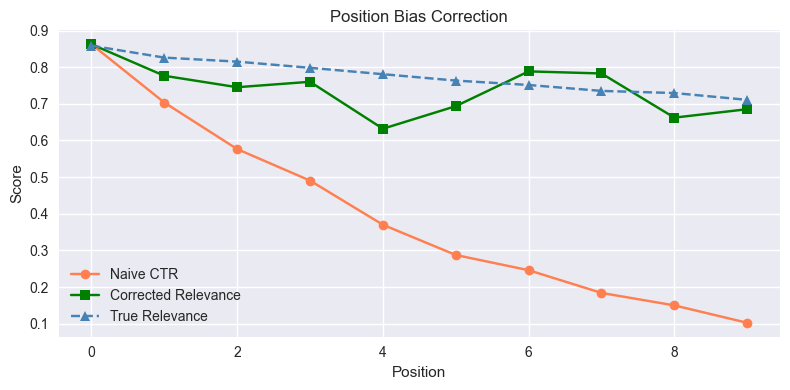

In [8]:
# Use estimated examination probs to debias click data
# Corrected relevance estimate: P(rel|item) = P(click) / P(examine|position)

click_df['est_exam'] = click_df['position'].apply(lambda p: max(estimated_exam[p], 0.01))
click_df['corrected_relevance'] = click_df['clicked'] / click_df['est_exam']

# Compare naive vs corrected relevance by position
comparison = click_df.groupby('position').agg({
    'clicked': 'mean',
    'corrected_relevance': 'mean',
    'true_relevance': 'mean'
}).round(4)
comparison.columns = ['Naive CTR', 'Corrected Relevance', 'True Relevance']
print("\nPosition Bias Correction:")
print(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(comparison.index, comparison['Naive CTR'], 'o-', label='Naive CTR', color='coral')
ax.plot(comparison.index, comparison['Corrected Relevance'], 's-', label='Corrected Relevance', color='green')
ax.plot(comparison.index, comparison['True Relevance'], '^--', label='True Relevance', color='steelblue')
ax.set_xlabel('Position')
ax.set_ylabel('Score')
ax.set_title('Position Bias Correction')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Balanced Sampling for Training

Instead of re-weighting, we can balance the training data to reduce popularity bias:

1. **Uniform item sampling**: Sample items uniformly instead of proportionally to popularity
2. **Temperature sampling**: Apply temperature to the popularity distribution
3. **Inverse frequency sampling**: Sample proportional to $1/\text{count}$

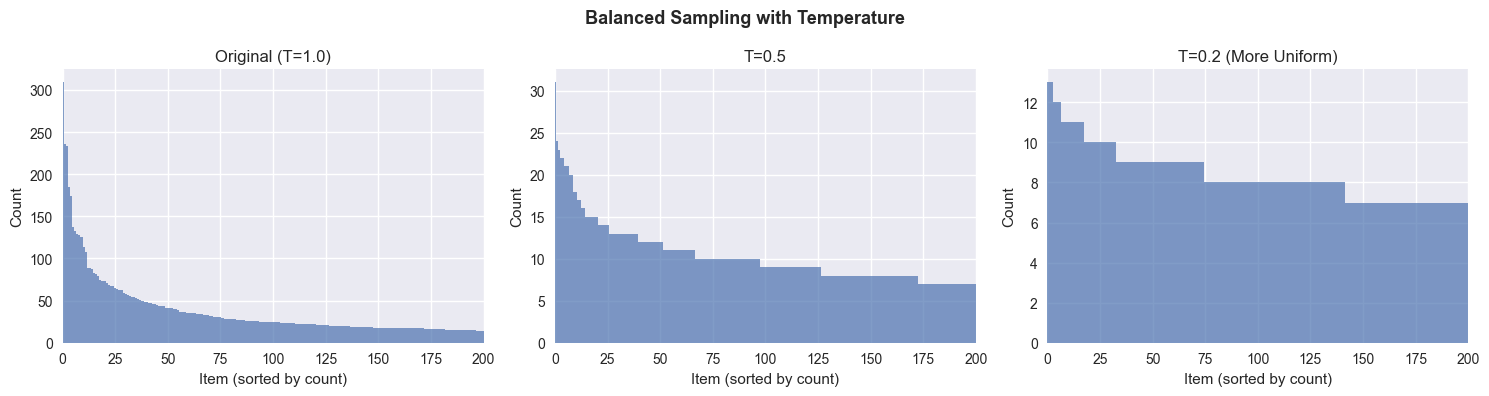

In [9]:
# Demonstrate balanced sampling
positive_items = inter_df[inter_df['clicked'] == 1]['item_id'].values

# Original distribution
item_counts = Counter(positive_items)
original_dist = np.array([item_counts.get(i, 0) for i in range(NUM_ITEMS)], dtype=float)
original_dist /= original_dist.sum()

# Temperature-based resampling
def temperature_resample(counts, temperature=0.5, n_samples=5000):
    """Resample items with temperature-adjusted distribution."""
    probs = counts ** temperature
    probs /= probs.sum()
    return rng.choice(len(counts), size=n_samples, p=probs)

original_counts = np.array([item_counts.get(i, 1) for i in range(NUM_ITEMS)], dtype=float)
samples_t05 = temperature_resample(original_counts, temperature=0.5)
samples_t02 = temperature_resample(original_counts, temperature=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in [
    (axes[0], positive_items, 'Original (T=1.0)'),
    (axes[1], samples_t05, 'T=0.5'),
    (axes[2], samples_t02, 'T=0.2 (More Uniform)'),
]:
    counts = Counter(data)
    sorted_items = sorted(counts.keys())
    sorted_vals = [counts[i] for i in sorted_items]
    ax.bar(range(len(sorted_vals)), sorted(sorted_vals, reverse=True), width=1.0, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Item (sorted by count)')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 200)  # show first 200 items

plt.suptitle('Balanced Sampling with Temperature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Exercises

### Exercise 1: Detect and Measure Popularity Bias

In [10]:
# 🏋️ Exercise 1: Popularity Bias Detection
#
# TODO:
# 1. Implement a function that takes recommendation lists and computes:
#    a. Average Recommendation Popularity (ARP): avg popularity of recommended items
#    b. Average Percentage of Long-Tail Items (APLT): fraction of non-popular items
#    c. Popularity-Relevance Correlation: correlation between item popularity and CTR
# 2. Compare these metrics for two simulated models:
#    - Model P (popularity-biased): recommends mostly popular items
#    - Model D (debiased): recommends from a balanced distribution

def popularity_bias_metrics(recommendations, item_popularity, ground_truth, popular_threshold=0.2):
    """Compute popularity bias metrics."""
    # --- YOUR CODE HERE ---
    pass
    # --- END YOUR CODE ---

# Generate two recommendation models and compare

### Exercise 2: Implement Position Bias Correction

In [11]:
# 🏋️ Exercise 2: Position Bias Correction for Training
#
# TODO:
# 1. Using the click_df data, train a simple scoring model:
#    a. Naive model: trained on raw clicks (biased)
#    b. IPW model: trained with position-aware propensity weights
# 2. For each model, predict relevance scores for items
# 3. Compare the correlation between predicted scores and true relevance
#
# Use a simple model: for each item, estimate relevance as weighted avg of clicks

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

### Exercise 3: Selection Bias Correction with IPW

In [12]:
# 🏋️ Exercise 3: Selection Bias Correction
#
# TODO: Using the MNAR rating data from Section 3:
# 1. Estimate the observation propensity for each (user, item) pair
#    using a logistic regression on item popularity
# 2. Compute the IPW-corrected mean rating and compare with:
#    a. Naive mean (from MNAR observed data)
#    b. True mean (from all ratings)
# 3. How much does IPW reduce the selection bias?

# --- YOUR CODE HERE ---

# --- END YOUR CODE ---

## Summary

In this notebook we covered:

- **Popularity bias**: the rich-get-richer feedback loop; measured by Gini index and long-tail coverage
- **Position bias**: higher positions get more clicks regardless of relevance; corrected via examination probability estimation
- **Selection bias**: we only observe outcomes for shown items; corrected via IPW
- **Conformity and exposure bias**: users follow norms and models reinforce their own choices
- **Debiasing methods**: IPW, balanced sampling, temperature-based sampling

**Key takeaway:** Every recommendation system suffers from multiple biases simultaneously. Understanding and correcting these biases is essential for fair evaluation and effective model training.